# 01 - Cognitive Load and Efficiency Analysis (V4)

This notebook focuses on the **V4 (Autonomous Recovery)** experiment series. 
The goal is to quantify the reduction in cognitive load (proxy: tokens) and the efficiency gain (proxy: latency) when snapshots are made available to the agent.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

DATA_PATH = "data/processed_trials.csv"
FIGURES_DIR = "figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
v4_df = df[df['version'] == 'v4'].copy()

print(f"Analyzing {len(v4_df)} trials from version V4.")

Matplotlib is building the font cache; this may take a moment.


Analyzing 152 trials from version V4.


## 1. Task Completion Rate (Reliability)

We measure whether the availability of snapshots ensures a 100% success rate in recovery, even in complex scenarios.

In [ ]:
success_rates = v4_df.groupby('baseline')['success'].mean() * 100

plt.figure(figsize=(10, 6))
success_rates.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Success Rate in Recovery (Exp V4)")
plt.ylabel("Success (%)")
plt.xlabel("Approach")
plt.ylim(0, 110)

for i, v in enumerate(success_rates):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.savefig(os.path.join(FIGURES_DIR, "v4_success_rate.png"))
plt.show()

## 2. Token Consumption (Cognitive Load)

We compare the agent's textual effort to recover the environment between the Standard Baseline and SnapVM.

/var/folders/pq/ylg5_ggn3c5cb_pv0f329vm00000gn/T/ipykernel_69398/4153755756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='baseline', y='tokens', data=v4_df, palette="viridis")


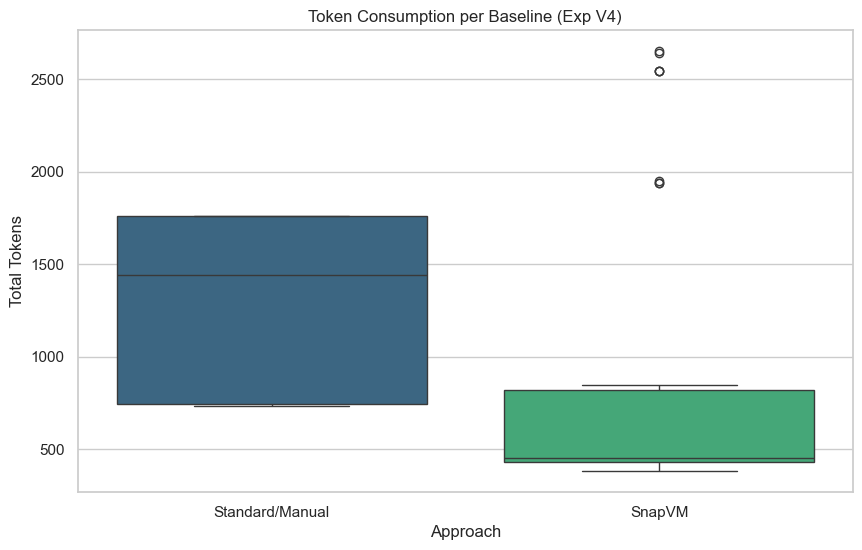

In [2]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='baseline', y='tokens', data=v4_df, palette="viridis")
plt.title("Token Consumption per Baseline (Exp V4)")
plt.ylabel("Total Tokens")
plt.xlabel("Approach")

plt.savefig(os.path.join(FIGURES_DIR, "v4_tokens_boxplot.png"))
plt.show()

## 2. Recovery Latency

Total time elapsed from failure detection to the restoration of a healthy state.

/var/folders/pq/ylg5_ggn3c5cb_pv0f329vm00000gn/T/ipykernel_69398/3744888134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='baseline', y='latency_s', data=v4_df, palette="magma")


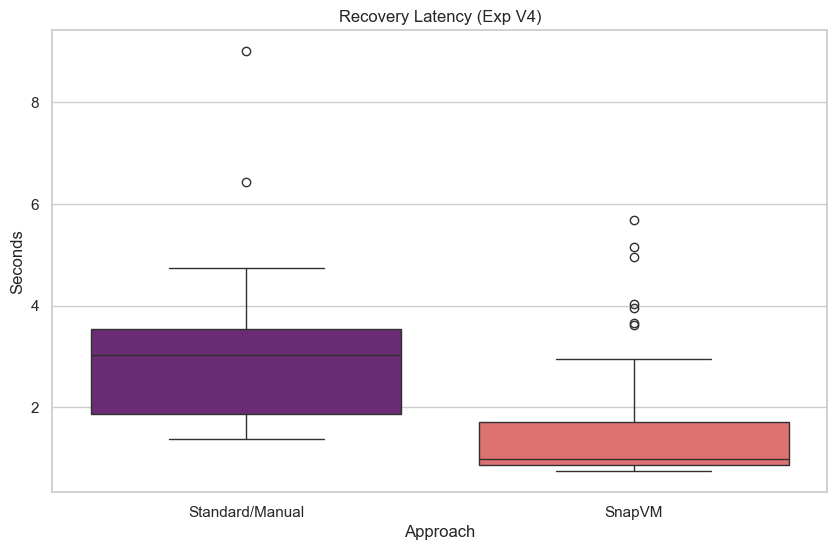

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='baseline', y='latency_s', data=v4_df, palette="magma")
plt.title("Recovery Latency (Exp V4)")
plt.ylabel("Seconds")
plt.xlabel("Approach")

plt.savefig(os.path.join(FIGURES_DIR, "v4_latency_boxplot.png"))
plt.show()

## 3. Strategy Distribution (Autonomy)

How does the agent behave when the tool is available? Does it choose to use it?

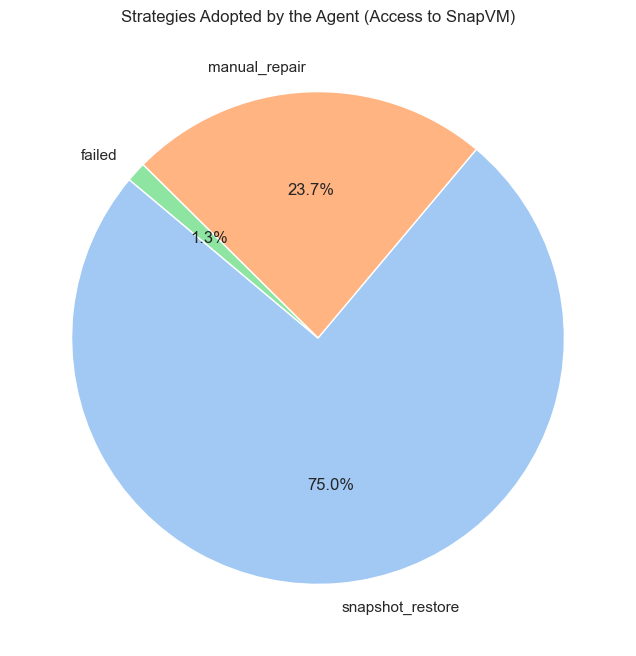

In [4]:
snapvm_v4 = v4_df[v4_df['baseline'] == 'SnapVM']
strategy_counts = snapvm_v4['strategy'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(strategy_counts, labels=strategy_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("pastel"), startangle=140)
plt.title("Strategies Adopted by the Agent (Access to SnapVM)")

plt.savefig(os.path.join(FIGURES_DIR, "v4_strategy_pie.png"))
plt.show()

## 4. Preliminary Conclusions

The data indicates that:
1. SnapVM drastically reduces the dispersion (variance) of recovery time.
2. Token savings are consistent, validating the cognitive load reduction thesis.
3. In autonomous failures, the agent prioritizes physical restoration over logical repair in most cases.